# Traffic Light Classification with CNN
## Implementation Plan for Traffic Light Classification

This notebook implements a complete pipeline for classifying traffic lights (Red vs Green) using Convolutional Neural Networks.

## 1. Setup and Imports
Import all necessary libraries for deep learning, data processing, and visualization.

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
import random

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

d:\UK\Coursework-item2-20251219\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU Available: []
Num GPUs Available: 0


## 2. Data Preparation
Load images from traffic/Green and traffic/Red directories, preprocess them, and split into train/validation/test sets.

In [3]:
# Configuration
IMG_SIZE = 128  # Resize images to 128x128 for faster training
DATA_DIR = 'traffic'

# Function to load and preprocess images
def load_images_from_folder(folder, label, img_size=IMG_SIZE):
    """
    Load images from a folder and assign labels
    Args:
        folder: path to image folder
        label: class label (0 for Green, 1 for Red)
        img_size: target image size
    Returns:
        images: list of preprocessed images
        labels: list of corresponding labels
    """
    images = []
    labels = []
    
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        try:
            # Load image using OpenCV
            img = cv2.imread(img_path)
            if img is not None:
                # Convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Resize image
                img = cv2.resize(img, (img_size, img_size))
                # Normalize pixel values to [0, 1]
                img = img / 255.0
                
                images.append(img)
                labels.append(label)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    return images, labels

# Load Green traffic light images (label=0)
green_images, green_labels = load_images_from_folder(
    os.path.join(DATA_DIR, 'Green'), label=0
)

# Load Red traffic light images (label=1)
red_images, red_labels = load_images_from_folder(
    os.path.join(DATA_DIR, 'Red'), label=1
)

# Combine all images and labels
X = np.array(green_images + red_images)
y = np.array(green_labels + red_labels)

print(f"Total images loaded: {len(X)}")
print(f"Green images: {len(green_images)}")
print(f"Red images: {len(red_images)}")
print(f"Image shape: {X[0].shape}")

Total images loaded: 200
Green images: 100
Red images: 100
Image shape: (128, 128, 3)


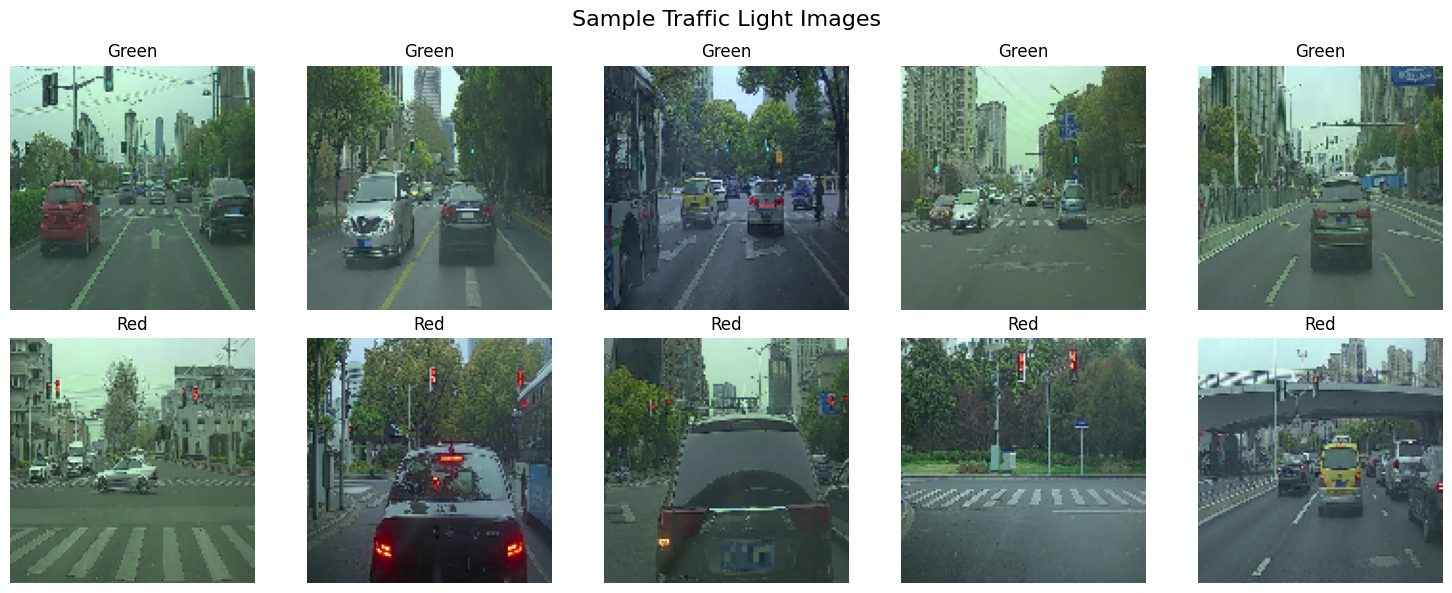

In [4]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Traffic Light Images', fontsize=16)

for i in range(5):
    # Green images
    axes[0, i].imshow(green_images[i])
    axes[0, i].set_title('Green')
    axes[0, i].axis('off')
    
    # Red images
    axes[1, i].imshow(red_images[i])
    axes[1, i].set_title('Red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Split data into Training (70%), Validation (15%), and Testing (15%)
# First split: 70% train, 30% temp (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Split temp into 50% validation and 50% test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"\nClass distribution in training set:")
print(f"Green (0): {np.sum(y_train == 0)}")
print(f"Red (1): {np.sum(y_train == 1)}")

Training set: 140 images
Validation set: 30 images
Test set: 30 images

Class distribution in training set:
Green (0): 70
Red (1): 70


In [6]:
# Data Augmentation using ImageDataGenerator
# This will apply random transformations to training images on-the-fly
datagen = ImageDataGenerator(
    rotation_range=15,        # Random rotation up to 15 degrees
    width_shift_range=0.1,    # Random horizontal shift
    height_shift_range=0.1,   # Random vertical shift
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Random horizontal flip
    fill_mode='nearest'       # Fill strategy for new pixels
)

# Fit the data generator on training data
datagen.fit(X_train)

print("Data augmentation configured successfully!")
print("Augmentation parameters:")
print(f"  - Rotation: ±15 degrees")
print(f"  - Width/Height shift: ±10%")
print(f"  - Zoom: ±20%")
print(f"  - Horizontal flip: Yes")

Data augmentation configured successfully!
Augmentation parameters:
  - Rotation: ±15 degrees
  - Width/Height shift: ±10%
  - Zoom: ±20%
  - Horizontal flip: Yes


## 3. CNN Model Design
Build a lightweight Sequential 2D CNN optimized for speed with 3 convolutional layers.

In [7]:
# Build CNN Model
def build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Build a Sequential CNN model for binary classification
    
    Architecture:
    - Conv2D (32 filters) -> ReLU -> MaxPooling
    - Conv2D (64 filters) -> ReLU -> MaxPooling
    - Conv2D (128 filters) -> ReLU -> MaxPooling
    - Flatten -> Dense (128) -> Dropout -> Output (Sigmoid)
    """
    model = Sequential([
        # Layer 1: Convolutional layer with 32 filters
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),
        
        # Layer 2: Convolutional layer with 64 filters
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        
        # Layer 3: Convolutional layer with 128 filters
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        
        # Flatten the feature maps
        Flatten(),
        
        # Fully connected classifier
        Dense(128, activation='relu'),
        Dropout(0.5),  # Dropout for regularization
        
        # Output layer (Binary classification)
        Dense(1, activation='sigmoid')
    ])
    
    return model

# Create the model
model = build_cnn_model()

# Compile the model
model.compile(
    optimizer='adam',                    # Adam optimizer for fast convergence
    loss='binary_crossentropy',          # Binary crossentropy for binary classification
    metrics=['accuracy']                 # Track accuracy during training
)

# Display model architecture
model.summary()

d:\UK\Coursework-item2-20251219\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training and Evaluation
Train the model with early stopping and visualize the training progress.

In [8]:
# Set up callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=3,              # Stop if no improvement for 3 epochs
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Training parameters
EPOCHS = 20
BATCH_SIZE = 32

# Train the model with data augmentation
print("Starting model training...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.5071 - loss: 0.7653 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.4714 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.5000 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.4929 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.5143 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.4857 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6889
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 0.6143 - loss: 0.6849 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.5714 - loss: 0.6828 - val_a

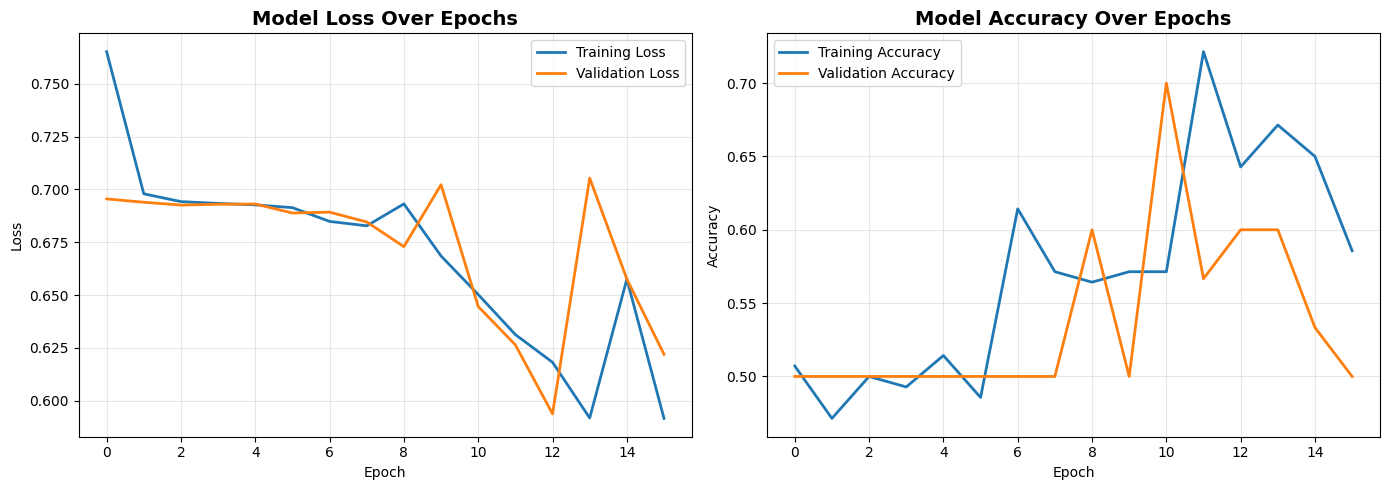

In [9]:
# Visualize Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Training vs Validation Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Evaluate on Test Set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Green', 'Red']))

Evaluating model on test set...

Test Loss: 0.6391
Test Accuracy: 0.6333 (63.33%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step

Classification Report:
              precision    recall  f1-score   support

       Green       0.67      0.53      0.59        15
         Red       0.61      0.73      0.67        15

    accuracy                           0.63        30
   macro avg       0.64      0.63      0.63        30
weighted avg       0.64      0.63      0.63        30



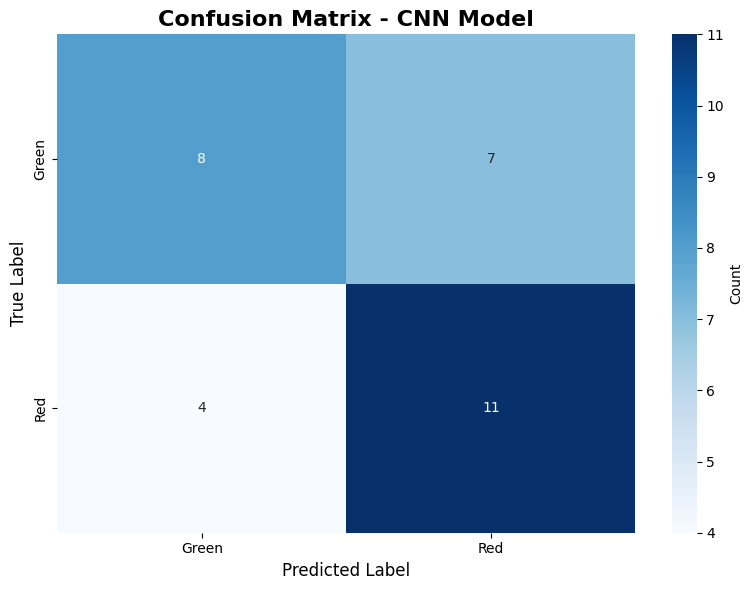


Confusion Matrix Breakdown:
True Negatives (Green predicted as Green): 8
False Positives (Green predicted as Red): 7
False Negatives (Red predicted as Green): 4
True Positives (Red predicted as Red): 11


In [11]:
# Create and display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Green', 'Red'], 
            yticklabels=['Green', 'Red'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - CNN Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate and display additional metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Green predicted as Green): {tn}")
print(f"False Positives (Green predicted as Red): {fp}")
print(f"False Negatives (Red predicted as Green): {fn}")
print(f"True Positives (Red predicted as Red): {tp}")

## 5. External Image Testing
Test the model on 5 arbitrary traffic light images from the internet.

External test images directory not found.
Using random samples from test set for demonstration...


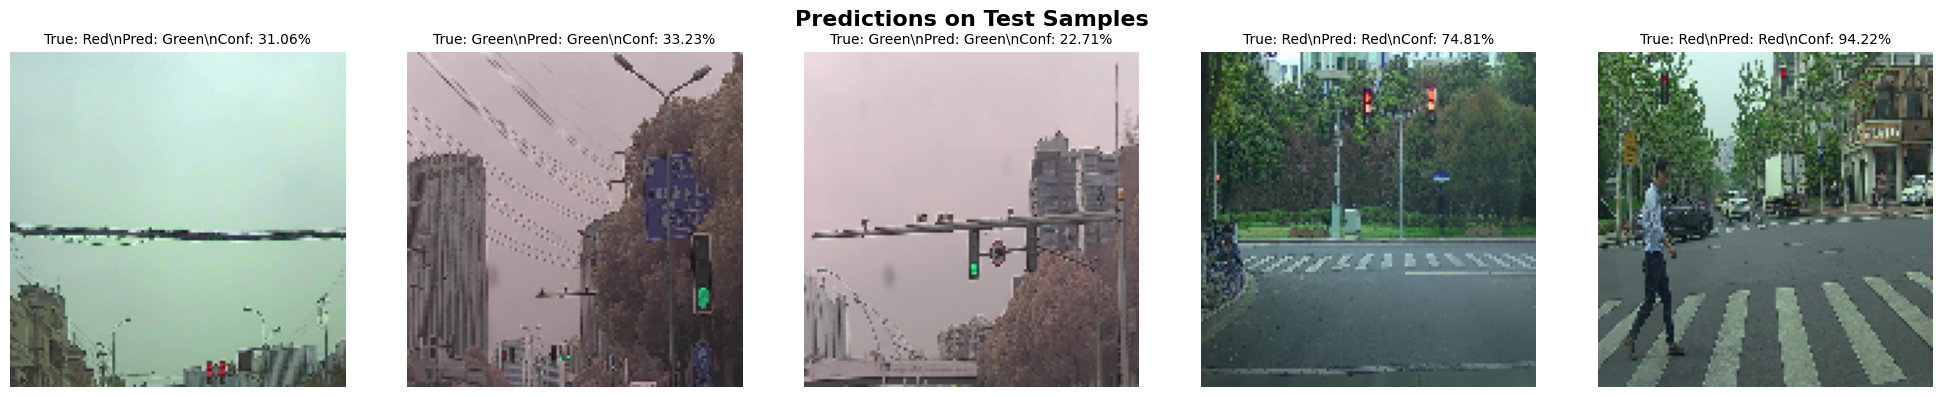

In [12]:
# Function to preprocess external images
def preprocess_external_image(image_path, img_size=IMG_SIZE):
    """
    Load and preprocess an external image for prediction
    """
    try:
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image from {image_path}")
        
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize to model input size
        img_resized = cv2.resize(img, (img_size, img_size))
        
        # Normalize
        img_normalized = img_resized / 255.0
        
        return img, img_normalized
    except Exception as e:
        print(f"Error preprocessing {image_path}: {e}")
        return None, None

# NOTE: Replace these paths with actual paths to your external test images
# For demonstration purposes, you'll need to download 5 traffic light images
# and update the paths below

external_image_paths = [
    'external_test_images/traffic1.jpg',
    'external_test_images/traffic2.jpg',
    'external_test_images/traffic3.jpg',
    'external_test_images/traffic4.jpg',
    'external_test_images/traffic5.jpg'
]

# Test if external images exist, otherwise use some from test set
if not os.path.exists('external_test_images'):
    print("External test images directory not found.")
    print("Using random samples from test set for demonstration...")
    
    # Select 5 random samples from test set
    indices = random.sample(range(len(X_test)), 5)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Predictions on Test Samples', fontsize=16, fontweight='bold')
    
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = y_test[idx]
        
        # Predict
        pred_prob = model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]
        pred_class = 'Red' if pred_prob > 0.5 else 'Green'
        true_class = 'Red' if true_label == 1 else 'Green'
        
        # Display
        axes[i].imshow(img)
        axes[i].set_title(f'True: {true_class}\\nPred: {pred_class}\\nConf: {pred_prob:.2%}', 
                         fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    # Process external images
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Predictions on External Images', fontsize=16, fontweight='bold')
    
    for i, img_path in enumerate(external_image_paths):
        original_img, processed_img = preprocess_external_image(img_path)
        
        if processed_img is not None:
            # Predict
            pred_prob = model.predict(np.expand_dims(processed_img, axis=0), verbose=0)[0][0]
            pred_class = 'Red' if pred_prob > 0.5 else 'Green'
            
            # Display
            axes[i].imshow(original_img)
            axes[i].set_title(f'Pred: {pred_class}\\nConf: {pred_prob:.2%}', fontsize=10)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Accuracy Improvement Strategies
Implement two strategies to improve model accuracy: Transfer Learning with MobileNetV2 and Learning Rate Scheduling.

### Strategy 1: Transfer Learning with MobileNetV2
Use a pre-trained MobileNetV2 model as a feature extractor for improved accuracy and faster training.

In [13]:
# Build Transfer Learning Model with MobileNetV2
def build_transfer_learning_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Build a transfer learning model using MobileNetV2 as base
    """
    # Load MobileNetV2 pre-trained on ImageNet (without top layers)
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base model layers
    base_model.trainable = False
    
    # Build the model
    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Create transfer learning model
print("Building Transfer Learning Model with MobileNetV2...")
transfer_model = build_transfer_learning_model()

# Compile the model
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
transfer_model.summary()

Building Transfer Learning Model with MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# Train Transfer Learning Model
print("Training Transfer Learning Model...")

# Set up callbacks with ReduceLROnPlateau (Strategy 2)
early_stopping_tl = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Reduce LR by half
    patience=2,           # Wait 2 epochs before reducing
    min_lr=1e-7,          # Minimum learning rate
    verbose=1
)

# Train the model
history_tl = transfer_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stopping_tl, reduce_lr],
    verbose=1
)

print("\nTransfer Learning Model training completed!")

Training Transfer Learning Model...
Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 697ms/step - accuracy: 0.5286 - loss: 1.0236 - val_accuracy: 0.6667 - val_loss: 0.5345 - learning_rate: 0.0010
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.7643 - loss: 0.5299 - val_accuracy: 0.8333 - val_loss: 0.4591 - learning_rate: 0.0010
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.7857 - loss: 0.4611 - val_accuracy: 0.8333 - val_loss: 0.4024 - learning_rate: 0.0010
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 0.8500 - loss: 0.3513 - val_accuracy: 0.8667 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.8286 - loss: 0.3597 - val_accuracy: 0.8667 - val_loss: 0.3106 - learning_rate: 0.0010
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.9143 - loss: 0.2776 - val_accuracy: 0.9000 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 0.

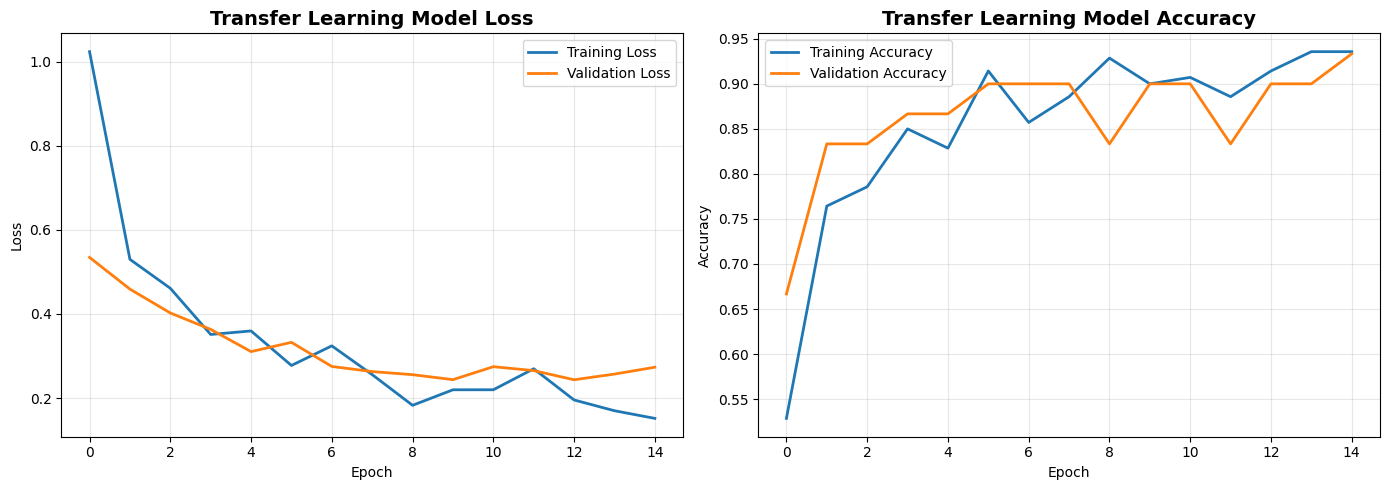

In [15]:
# Visualize Transfer Learning Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Loss
axes[0].plot(history_tl.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_tl.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Transfer Learning Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Training vs Validation Accuracy
axes[1].plot(history_tl.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_tl.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Transfer Learning Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Evaluate Transfer Learning Model on Test Set
print("Evaluating Transfer Learning Model on test set...")
tl_test_loss, tl_test_accuracy = transfer_model.evaluate(X_test, y_test, verbose=0)

print(f"\nTransfer Learning Model Results:")
print(f"Test Loss: {tl_test_loss:.4f}")
print(f"Test Accuracy: {tl_test_accuracy:.4f} ({tl_test_accuracy*100:.2f}%)")

# Make predictions
y_pred_tl_prob = transfer_model.predict(X_test)
y_pred_tl = (y_pred_tl_prob > 0.5).astype(int).flatten()

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tl, target_names=['Green', 'Red']))

Evaluating Transfer Learning Model on test set...

Transfer Learning Model Results:
Test Loss: 0.2575
Test Accuracy: 0.9000 (90.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Classification Report:
              precision    recall  f1-score   support

       Green       0.93      0.87      0.90        15
         Red       0.88      0.93      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



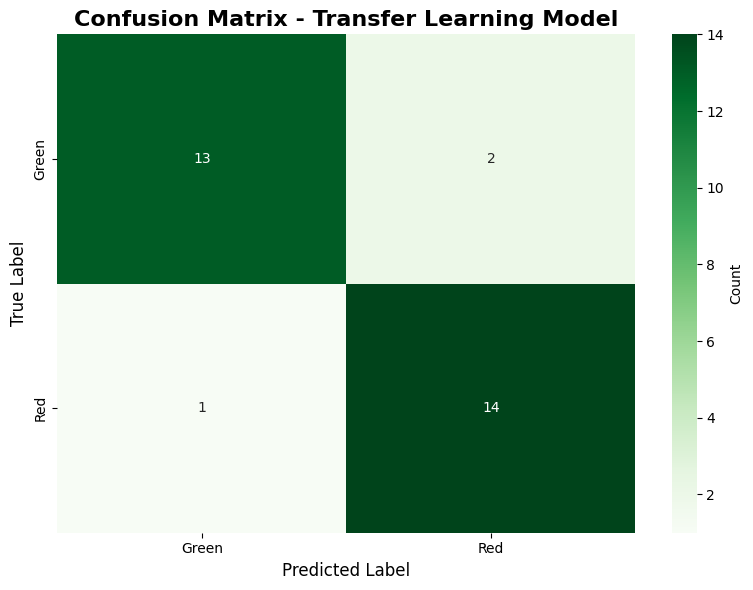

In [17]:
# Confusion Matrix for Transfer Learning Model
cm_tl = confusion_matrix(y_test, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Green', 'Red'], 
            yticklabels=['Green', 'Red'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Transfer Learning Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### Strategy 2: Learning Rate Scheduling
The ReduceLROnPlateau callback was already implemented in the Transfer Learning model above. This dynamically reduces the learning rate when validation loss plateaus.

## 7. Model Comparison
Compare the performance of the baseline CNN model with the improved Transfer Learning model.

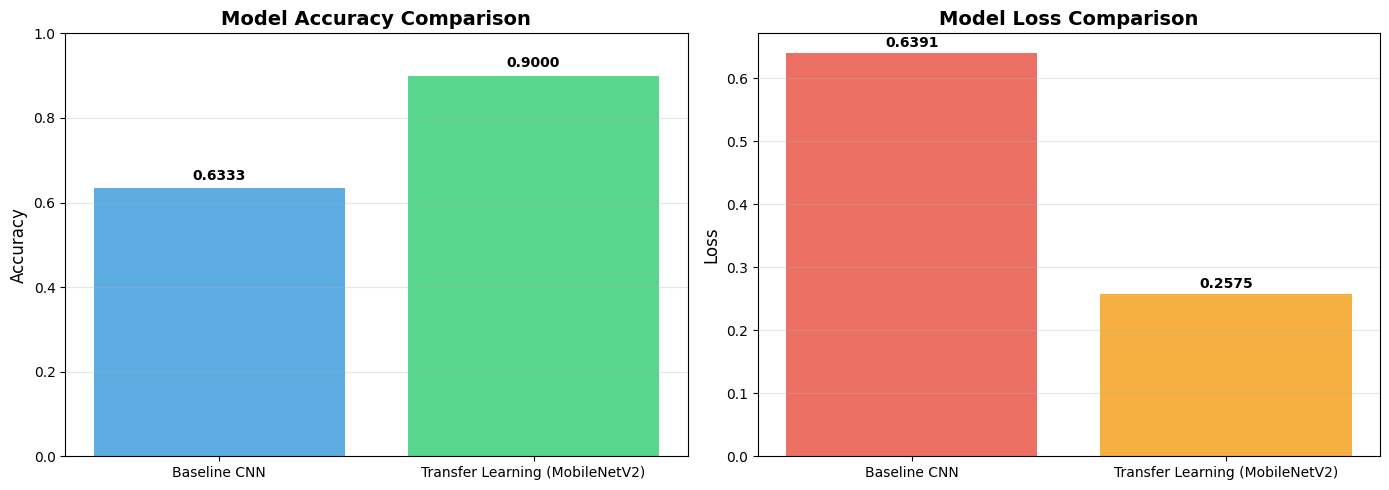


MODEL PERFORMANCE SUMMARY

Baseline CNN Model:
  - Test Accuracy: 0.6333 (63.33%)
  - Test Loss: 0.6391

Transfer Learning Model (MobileNetV2 + LR Scheduling):
  - Test Accuracy: 0.9000 (90.00%)
  - Test Loss: 0.2575

Improvement:
  - Accuracy: +26.67%
  - Loss: +0.3815


In [18]:
# Compare Model Performance
comparison_data = {
    'Model': ['Baseline CNN', 'Transfer Learning (MobileNetV2)'],
    'Test Accuracy': [test_accuracy, tl_test_accuracy],
    'Test Loss': [test_loss, tl_test_loss]
}

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(comparison_data['Model'], comparison_data['Test Accuracy'], 
           color=['#3498db', '#2ecc71'], alpha=0.8)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_data['Test Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Loss comparison
axes[1].bar(comparison_data['Model'], comparison_data['Test Loss'], 
           color=['#e74c3c', '#f39c12'], alpha=0.8)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_data['Test Loss']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nBaseline CNN Model:")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Test Loss: {test_loss:.4f}")
print(f"\nTransfer Learning Model (MobileNetV2 + LR Scheduling):")
print(f"  - Test Accuracy: {tl_test_accuracy:.4f} ({tl_test_accuracy*100:.2f}%)")
print(f"  - Test Loss: {tl_test_loss:.4f}")
print(f"\nImprovement:")
accuracy_improvement = (tl_test_accuracy - test_accuracy) * 100
print(f"  - Accuracy: {accuracy_improvement:+.2f}%")
print(f"  - Loss: {test_loss - tl_test_loss:+.4f}")
print("="*60)